# 07f - Modelagem: Redes Neurais (ANN/MLP)
Neste notebook, exploramos **Multilayer Perceptron (MLP)** para capturar complexidades não lineares nos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Base carregada: {df.shape[0]} registros.")

📦 Base carregada: 191 registros.


In [2]:
# Validação da Base 2023-2025
print(f"📊 Shape da base: {df.shape}")
print(f"📅 Período: {df['data'].min()} até {df['data'].max()}")

📊 Shape da base: (191, 52)
📅 Período: 2023-08-01 00:00:00 até 2025-08-22 00:00:00


In [3]:
# 1. Configuração de Features Selecionadas
X = df.drop(columns=['data', 'total_servido'])
y = df['total_servido']
features_list = X.columns.tolist()

# 2. Divisão Treino/Teste (Temporal) - 80/20
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"✅ Utilizando {len(features_list)} features selecionadas.")
print(f"📈 Treino: {len(X_train)} dias | Teste: {len(X_test)} dias")

✅ Utilizando 50 features selecionadas.
📈 Treino: 152 dias | Teste: 39 dias


In [4]:
# 3. Escalonamento de Features (Essencial para Redes Neurais)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features escalonadas com sucesso.")

✅ Features escalonadas com sucesso.


📊 Performance MLP:
MAE: 28.97
R2: -0.01


c:\Users\miche\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


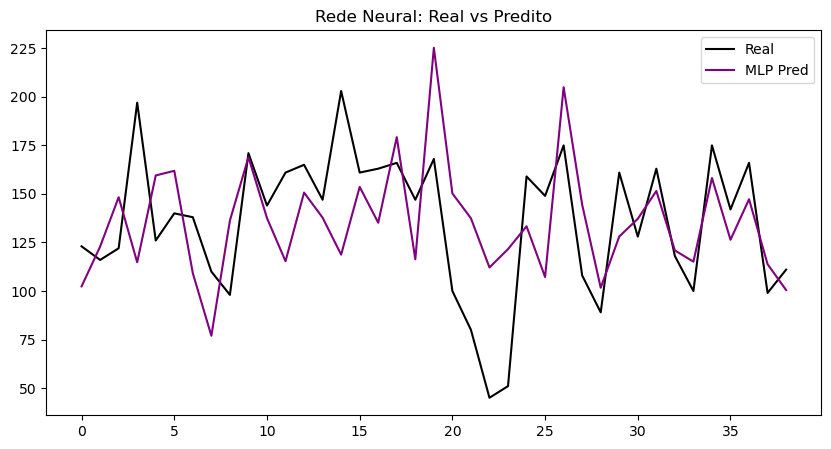

In [5]:
# Treinamento MLP
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)

preds = mlp.predict(X_test_scaled)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"📊 Performance MLP:")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Real', color='black')
plt.plot(preds, label='MLP Pred', color='purple')
plt.title('Rede Neural: Real vs Predito')
plt.legend()
plt.show()